In [1]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import string
spacy.require_gpu()

nlp = spacy.load("en_core_web_sm", disable=["tok2vec", "ner"])
nlp.max_length = 3_000_000 # needed for long documents, otherwise spaCy cannot handle that many tokens

nlp.disable_pipe("parser")
nlp.enable_pipe("senter")

# IMPORTANT NOTE: THESE STATS ARE ONLY FOR THE TESTING DATASET; THE ORIGINAL AUTHORS DID SOME STATS AS WELL BUT ON THE ENTIRE DATASET
multi_lexsum = load_dataset("allenai/multi_lexsum", name="v20230518", trust_remote_code=True)
eurlexsum = load_dataset("dennlinger/eur-lex-sum", "english")

ValueError: Cannot use GPU, CuPy is not installed

In [ ]:
nlp.pipe_names

['tagger', 'senter', 'attribute_ruler', 'lemmatizer']

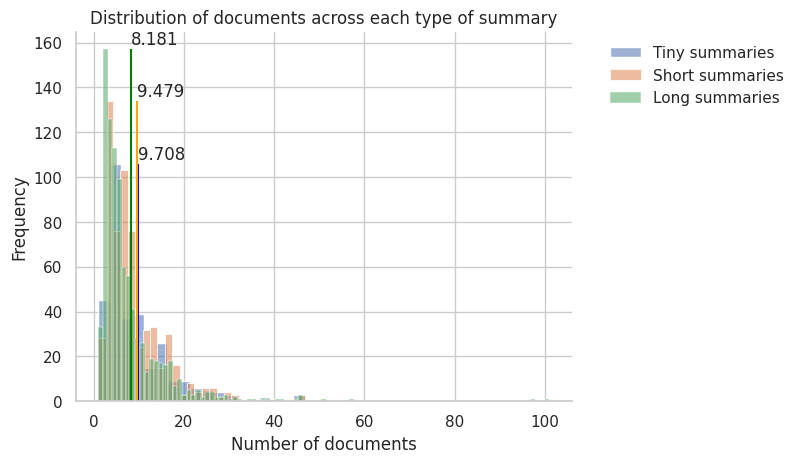

In [ ]:
def make_plot(data, title):
    color_vline = {
        "tiny": "blue",
        "short": "orange", 
        "long": "green",
        "all": "red"
    }
    fig = sns.histplot(data, alpha=0.55, label=title.title() + " " + "summaries")
    
    bin_heights = [patch.get_height() for patch in fig.patches]

    plt.vlines(x=[np.mean(data)], ymin=[0], ymax=[np.max(bin_heights)], colors=[color_vline[title]])
    plt.text(x=np.mean(data), y=np.max(bin_heights)+2, s=f"{np.mean(data):.3f}")

    sns.despine()
    plt.title("Distribution of documents across each type of summary")
    plt.xlabel("Number of documents")
    plt.ylabel("Frequency")
    return fig

summ_types = ["tiny", "short", "long"]

sns.set_theme(style="whitegrid")
for summ in summ_types:
    if summ != "all":
        aux_data = multi_lexsum["test"].filter(lambda x: x[f"summary/{summ}"] != None)
    else:
        aux_data = multi_lexsum["test"]
    aux_len = [len(d) for d in aux_data["sources"]]
    make_plot(aux_len, summ)
    # plt.show()

plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

In [ ]:
from tqdm import tqdm
import torch

punctuation = set(string.punctuation) | set(["\n"])
def count_spacy(docket):
    aux = nlp.pipe(docket, batch_size=1)
    words = 0
    sents = 0
    b = 0

    # for doc in tqdm(aux, total=len(docket)):
    for doc in aux:
        sents += len(list(doc.sents))
        words += sum([1 for word in doc if word.text not in punctuation])
        torch.cuda.empty_cache()

    return words, sents

In [ ]:
# ex = multi_lexsum["test"]["sources"][3]
# count_spacy(ex)

In [ ]:
from tqdm import tqdm

def make_plot(data, title):
    color_vline = {
        "tiny": "blue",
        "short": "orange", 
        "long": "green",
        "all": "red"
    }
    fig = sns.histplot(data, alpha=0.55, label=title.title() + " " + "summaries")
    
    bin_heights = [patch.get_height() for patch in fig.patches]

    plt.vlines(x=[np.mean(data)], ymin=[0], ymax=[np.max(bin_heights)], colors=[color_vline[title]])
    plt.text(x=np.mean(data), y=np.max(bin_heights)+2, s=f"{np.mean(data):.3f}")

    sns.despine()
    plt.title("Distribution of documents across each type of summary")
    plt.xlabel("Number of documents")
    plt.ylabel("Frequency")
    return fig

summ_types = ["tiny", "short", "long"]
stats_summ = {}
for summ in summ_types:
    aux_data = multi_lexsum["test"].filter(lambda x: x[f"summary/{summ}"] != None)
 
    aux_count = np.asarray([count_spacy(docket) for docket in tqdm(aux_data["sources"])])
    stats_summ[summ] = aux_count
    # make_plot(aux_len, summ)
    # plt.show()

# plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

100%|██████████| 908/908 [18:42<00:00,  1.24s/it]  


In [ ]:
from tqdm import tqdm

def make_plot(data, title):
    color_vline = {
        "tiny": "blue",
        "short": "orange", 
        "long": "green",
        "all": "red"
    }
    fig = sns.histplot(data, alpha=0.55, label=title.title() + " " + "summaries")
    
    bin_heights = [patch.get_height() for patch in fig.patches]

    plt.vlines(x=[np.mean(data)], ymin=[0], ymax=[np.max(bin_heights)], colors=[color_vline[title]])
    plt.text(x=np.mean(data), y=np.max(bin_heights)+2, s=f"{np.mean(data):.3f}")

    sns.despine()
    plt.title("Distribution of documents across each type of summary")
    plt.xlabel("Number of documents")
    plt.ylabel("Frequency")
    return fig

summ_types = ["test", "validation"]
stats_summ = {}
for summ in summ_types:
    aux_data = eurlexsum[summ]
    aux_count = np.asarray([count_spacy([docket]) for docket in tqdm(aux_data["reference"])])
    stats_summ[summ] = aux_count
    # make_plot(aux_len, summ)
    # plt.show()

# plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

100%|██████████| 187/187 [01:32<00:00,  2.03it/s]


In [ ]:
# [8.40495449e+04 9.70833333e+00]
# [7.68766445e+04 9.47889610e+00]
# [5.73333678e+04 8.18061674e+00]

In [ ]:
print(np.mean(stats_summ["test"], axis=0))
print(np.mean(stats_summ["validation"], axis=0))

[19336.64361702   528.95744681]
[19158.40106952   515.04278075]


In [ ]:
print(np.mean(stats_summ["tiny"], axis=0))
print(np.mean(stats_summ["short"], axis=0))
print(np.mean(stats_summ["long"], axis=0))

KeyError: 'tiny'

In [ ]:

a = list(nlp(multi_lexsum["test"]["sources"][0][0]).sents)